<a href="https://colab.research.google.com/github/hamzaghoudrani/TP1/blob/main/Tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import (Conv2D, MaxPooling2D,
                                     Activation, Flatten, Dense, Dropout)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/v_data.zip', 'r') as z:
  z.extractall('/content/')

In [ ]:
# Resize all images to 224x224 pixels before feeding them to the model.
# This ensures all inputs have the same shape.
img_width, img_height = 224, 224

In [ ]:
train_data_dir      = '/content/v_data/train'
validation_data_dir = '/content/v_data/test'

In [ ]:
nb_train_samples      = 400   # 400 images for training
nb_validation_samples = 100   # 100 images for validation

# Training hyperparameters
epochs     = 15    # number of times the model sees the full training set
batch_size = 16    # number of images processed together in one step
num_filters = 8    # number of filters in the convolutional layer
filter_size = 3    # each filter is 3x3 pixels

In [ ]:
# The 3 represents the 3 color channels: Red, Green, Blue
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

In [ ]:
# We want to evaluate on real, unmodified images.
train_datagen = ImageDataGenerator(
    rescale          = 1. / 255,
    shear_range      = 0.2,
    zoom_range       = 0.2,
    horizontal_flip  = True
)

test_datagen = ImageDataGenerator(rescale = 1. / 255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical'
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
# Model pipeline:
# Input (224x224x3) → Conv2D(8, 3x3) → ReLU → MaxPool(2x2) →
# Flatten (98,568) → Dense(24) → Dense(2) → Sigmoid

In [ ]:
model = Sequential()

In [ ]:
# Convolutional layer: 8 filters of size 3x3, applied on the input image
# Each filter learns to detect a different visual pattern (edges, textures, etc.)
model.add(Conv2D(num_filters, (filter_size, filter_size), input_shape=input_shape))

In [ ]:
# This is applied after convolution to add non-linearity
model.add(Activation('relu'))

In [ ]:
# This reduces the spatial size by half and makes the model more robust
# to small translations in the image
model.add(MaxPooling2D(pool_size=(2, 2)))


In [ ]:
# This is required before Dense layers which expect 1D input
model.add(Flatten())

In [ ]:
# This layer learns high-level combinations of the extracted features
model.add(Dense(24))

In [ ]:
model.add(Dense(2))

# Sigmoid activation on the output: gives a probability for each class
# Values are between 0 and 1
model.add(Activation('sigmoid'))

print(model.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'rmsprop',
    metrics   = ['accuracy']
)

# model.fit() trains the model.
# steps_per_epoch = total_samples // batch_size
#   = how many batches to process before calling it one epoch
# validation_steps = same logic but for validation data

history = model.fit(
    train_generator,
    steps_per_epoch  = nb_train_samples // batch_size,
    epochs           = epochs,
    validation_data  = validation_generator,
    validation_steps = nb_validation_samples // batch_size
)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.5625 - loss: 14.5981 - val_accuracy: 0.7292 - val_loss: 0.8590
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.6850 - loss: 2.2310 - val_accuracy: 0.8438 - val_loss: 0.6369
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step - accuracy: 0.7850 - loss: 0.8943 - val_accuracy: 0.8333 - val_loss: 0.4073
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.8350 - loss: 0.4507 - val_accuracy: 0.6667 - val_loss: 0.8595
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.8450 - loss: 0.4296 - val_accuracy: 0.7604 - val_loss: 0.7317
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 265ms/step - accuracy: 0.8575 - loss: 0.4097 - val_accuracy: 0.7083 - val_loss: 0.7163
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.8625 - loss: 0.3725 - val_accuracy: 0.7500 - val_loss: 0.7218
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.8825 - loss: 0.3474 - val_accuracy: 0

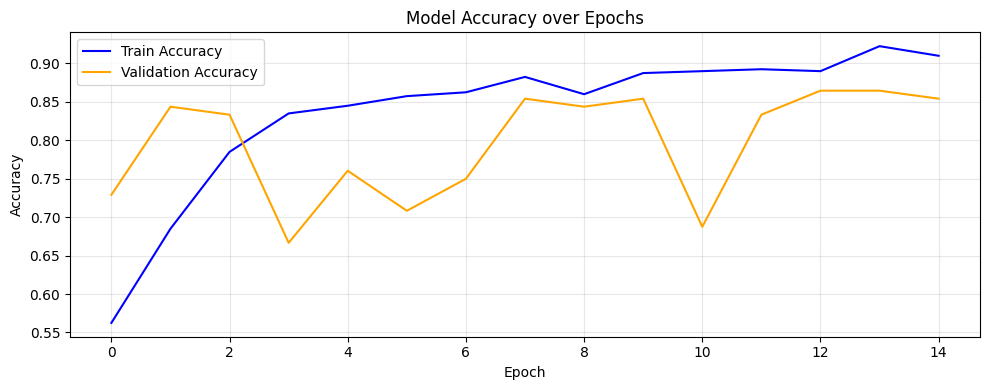

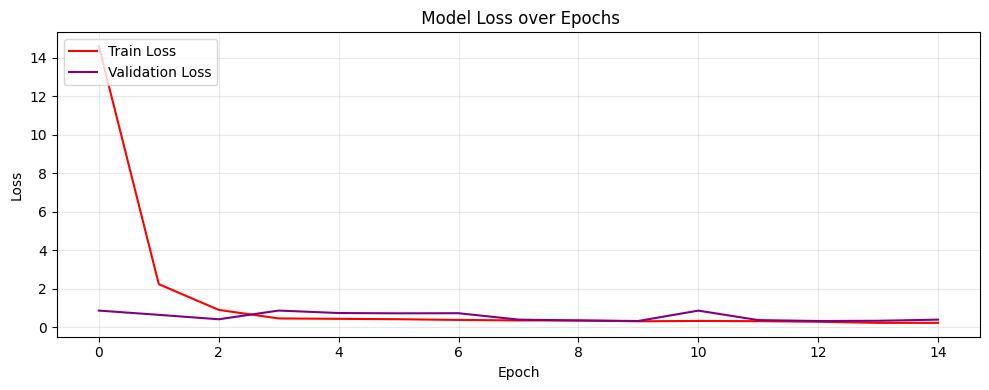

In [ ]:
# Accuracy plot
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  color='orange')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Loss plot
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss',      color='red')
plt.plot(history.history['val_loss'], label='Validation Loss',  color='purple')
plt.title(' Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#3. Training WITHOUT data augmentation

 # Without augmentation: only 400 images → model tends to overfit
# Memorizes training data → high train accuracy but lower val accuracy
# Train-val accuracy gap will be significant

# Augmentation adds regularization by creating varied versions of each image
# This makes the model more robust and reduces overfitting

In [ ]:
# Same generator but without shear, zoom, and flip
train_datagen_no_aug = ImageDataGenerator(rescale=1. / 255)

train_generator_no_aug = train_datagen_no_aug.flow_from_directory(
    train_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical'
)

Found 400 images belonging to 2 classes.


In [ ]:
# Same validation generator (never augmented)
validation_generator_ex3 = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical'
)

Found 100 images belonging to 2 classes.


In [ ]:
# Rebuild the same original model from scratch
model_3 = Sequential([
    Conv2D(8, (3, 3), input_shape=input_shape),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(24),
    Dense(2),
    Activation('sigmoid')
])

model_3.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'rmsprop',
    metrics   = ['accuracy']
)

history_3 = model_3.fit(
    train_generator_no_aug,
    steps_per_epoch  = nb_train_samples // batch_size,
    epochs           = epochs,
    validation_data  = validation_generator_ex3,
    validation_steps = nb_validation_samples // batch_size
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6200 - loss: 8.4550 - val_accuracy: 0.8750 - val_loss: 1.7374
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8350 - loss: 0.6515 - val_accuracy: 0.8021 - val_loss: 0.5525
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8950 - loss: 0.3129 - val_accuracy: 0.8333 - val_loss: 0.4088
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9700 - loss: 0.1217 - val_accuracy: 0.7292 - val_loss: 0.7207
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9600 - loss: 0.1300 - val_accuracy: 0.8438 - val_loss: 0.4438
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9975 - loss: 0.0207 - val_accuracy: 0.8542 - val_loss: 0.4448
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9750 - loss: 0.1448 - val_accuracy: 0.8229 - val_loss: 0.7143
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.0134 - val_accuracy: 0.8333 - v

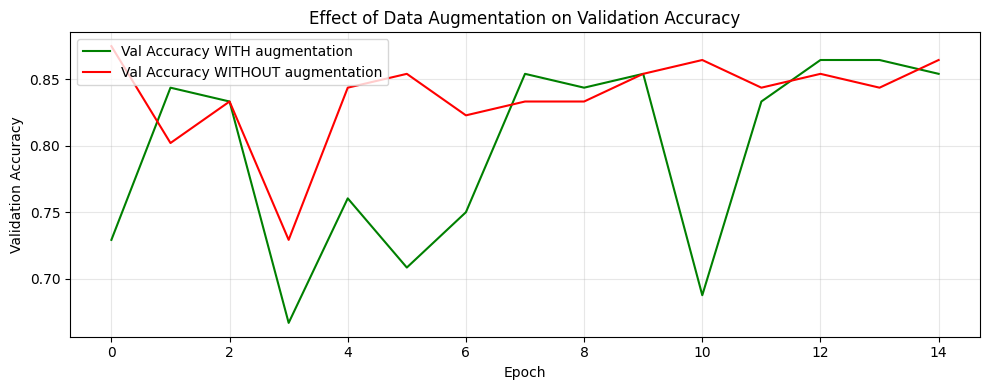

In [ ]:
# Compare: augmentation vs no augmentation
plt.figure(figsize=(10, 4))
plt.plot(history.history['val_accuracy'],     label='Val Accuracy WITH augmentation',    color='green')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy WITHOUT augmentation', color='red')
plt.title('Effect of Data Augmentation on Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#4. New CNN architecture with multiple conv layers and Dropout regularization

new architecture adds:

   # Deeper architecture improvements:
# - Conv blocks: 32 filters (shapes/textures), 64 filters (high-level features)
# - Dropout(0.5) before Dense layers to prevent overfitting
# - Dense(128) for better classification
# - Adam optimizer (faster convergence than RMSprop)
# - Softmax output (better for multi-class than sigmoid)

More conv layers → the model learns richer representations

Dropout → less overfitting on the small dataset

Adam → faster and more stable convergence


In [ ]:
model_4 = Sequential([

    # Block 1: detect low-level features (edges, colors) ---
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: detect mid-level features (shapes, patterns) ---
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: detect high-level features (object parts) ---
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Convert 2D feature maps to 1D vector
    Flatten(),

    # Dropout: randomly disables 50% of neurons to prevent overfitting
    Dropout(0.5),

    # Fully connected layer for high-level reasoning
    Dense(128, activation='relu'),

    # Output layer: 2 neurons for 2 classes (car, plane)
    # softmax: outputs probabilities that sum to 1 across all classes
    Dense(2, activation='softmax')
])

print(model_4.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Using categorical_crossentropy with softmax output
# (more appropriate than binary_crossentropy for multi-class)
model_4.compile(
    loss      = 'categorical_crossentropy',
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics   = ['accuracy']
)

# Using augmented data generator from Exercise 1
train_generator_ex4 = train_datagen.flow_from_directory(
    train_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical'
)

validation_generator_ex4 = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical'
)

history_4 = model_4.fit(
    train_generator_ex4,
    steps_per_epoch  = nb_train_samples // batch_size,
    epochs           = epochs,
    validation_data  = validation_generator_ex4,
    validation_steps = nb_validation_samples // batch_size
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.5400 - loss: 1.2225 - val_accuracy: 0.7708 - val_loss: 0.5620
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.7950 - loss: 0.5144 - val_accuracy: 0.8125 - val_loss: 0.4580
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.8425 - loss: 0.4169 - val_accuracy: 0.8646 - val_loss: 0.3018
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.8725 - loss: 0.3180 - val_accuracy: 0.8438 - val_loss: 0.4052
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.8900 - loss: 0.2890 - val_accuracy: 0.8542 - val_loss: 0.3945
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.9125 - loss: 0.2482 - val_accuracy: 0.8750 - val_loss: 0.2736
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 0.9100 - loss: 0.2401 - val_accuracy: 0.8750 - val_loss: 0.3604
Epoch 8/15
25/25 ━━━━

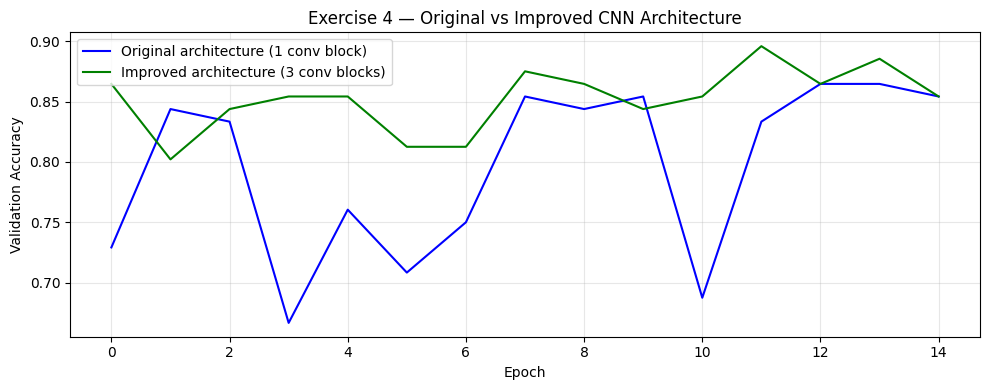

In [ ]:
# Compare original vs improved architecture
plt.figure(figsize=(10, 4))
plt.plot(history.history['val_accuracy'],     label='Original architecture (1 conv block)',  color='blue')
plt.plot(history_ex4.history['val_accuracy'], label='Improved architecture (3 conv blocks)', color='green')
plt.title('Exercise 4 — Original vs Improved CNN Architecture')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#5. Grayscale classification (luminance only)

To classify images using only luminance (grayscale = 1 channel),
we need to make some changes :

First we change color_mode='grayscale' in flow_from_directory()
this tells the generator to load images as single-channel
grayscale instead of 3-channel RGB.

second we change also input_shape changes from (224, 224, 3) to (224, 224, 1)
Since grayscale images have only 1 channel instead of 3,we update the input shape accordingly.

In [ ]:
# CHANGE 1: input shape uses 1 channel instead of 3
if K.image_data_format() == 'channels_first':
    input_shape_gray = (1, img_width, img_height)
else:
    input_shape_gray = (img_width, img_height, 1)  # ← only change here

train_datagen_gray = ImageDataGenerator(
    rescale         = 1. / 255,
    shear_range     = 0.2,
    zoom_range      = 0.2,
    horizontal_flip = True
)

test_datagen_gray = ImageDataGenerator(rescale=1. / 255)

In [ ]:
# CHANGE 2: color_mode='grayscale' → loads images as 1-channel
train_generator_gray = train_datagen_gray.flow_from_directory(
    train_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical',
    color_mode  = 'grayscale'          # only change here
)

validation_generator_gray = test_datagen_gray.flow_from_directory(
    validation_data_dir,
    target_size = (img_width, img_height),
    batch_size  = batch_size,
    class_mode  = 'categorical',
    color_mode  = 'grayscale'          # only change here
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
# Model is identical to Exercise 1, only input_shape changes
model_5 = Sequential([
    Conv2D(8, (3, 3), input_shape=input_shape_gray),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(24),
    Dense(2),
    Activation('sigmoid')
])

model_5.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'rmsprop',
    metrics   = ['accuracy']
)

history_5 = model_5.fit(
    train_generator_gray,
    steps_per_epoch  = nb_train_samples // batch_size,
    epochs           = epochs,
    validation_data  = validation_generator_gray,
    validation_steps = nb_validation_samples // batch_size
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.4975 - loss: 9.1173 - val_accuracy: 0.5104 - val_loss: 2.2214
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7250 - loss: 2.6160 - val_accuracy: 0.9167 - val_loss: 0.3911
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7675 - loss: 1.1365 - val_accuracy: 0.8750 - val_loss: 0.4408
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.8600 - loss: 0.5811 - val_accuracy: 0.8646 - val_loss: 0.3772
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.8350 - loss: 0.5020 - val_accuracy: 0.8542 - val_loss: 0.3277
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8675 - loss: 0.3915 - val_accuracy: 0.8125 - val_loss: 0.4986
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8700 - loss: 0.3815 - val_accuracy: 0.6458 - val_loss: 0.9276
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8575 - loss: 0.3642 - val_accuracy: 0.8229 - 

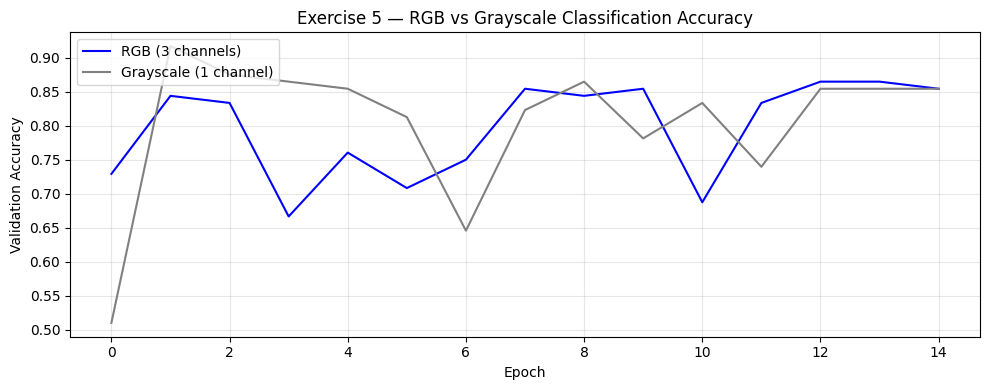

In [ ]:
# Compare RGB vs Grayscale
plt.figure(figsize=(10, 4))
plt.plot(history.history['val_accuracy'],     label='RGB (3 channels)',         color='blue')
plt.plot(history_5.history['val_accuracy'], label='Grayscale (1 channel)',     color='gray')
plt.title('Exercise 5 — RGB vs Grayscale Classification Accuracy')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

print("="*55)
print(f"  Original model (with augmentation)  : "
      f"val_acc = {max(history.history['val_accuracy']):.2%}")
print(f"  No augmentation                      : "
      f"val_acc = {max(history_3.history['val_accuracy']):.2%}")
print(f"  Improved architecture (3 conv blocks): "
      f"val_acc = {max(history_4.history['val_accuracy']):.2%}")
print(f"  Grayscale input                      : "
      f"val_acc = {max(history_5.history['val_accuracy']):.2%}")
print("="*55)

  Original model (with augmentation)  : val_acc = 86.46%
  No augmentation                      : val_acc = 87.50%
  Improved architecture (3 conv blocks): val_acc = 90.62%
  Grayscale input                      : val_acc = 91.67%
